<a href="https://colab.research.google.com/github/pabloecheg/Unsupervised-Learning/blob/main/Parcial_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install googletrans==4.0.0-rc1
!pip install unidecode
!pip install pyLDAvis

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 1.4 MB/s eta 0:00:00
  Created wheel for googletrans: filename=googletrans-4.0.0rc1-py3-none-any.whl size=17397 sha256=4e6de9b7236bb058759822650c1322b00e54a33c3d33fb9afbf4b71fa56bb68b
  Stored in directory: /root/.cache/pip/wheels/c0/59/9f/7372f0cf70160fe61b528532e1a7c8498c4becd6bcffb022de
Successfully built googletrans
  Attempting uninstall: chardet
    Found existing installation: chardet 5.2.0
    Uninstalling chardet-5.2.0:


In [ ]:
from google.colab import drive # conectar con datos de drive
drive.mount('/content/gdrive')
from googletrans import Translator # libreria para traducir
import pandas as pd # manejo de data frame
import numpy as np # manejos matriciales
import nltk # paquete 1 de lenguaje natural
import spacy # paquete 2 de lenguaje natural
import re # paquete 2 de lenguaje natural
from textblob import TextBlob  #
from unidecode import unidecode
import seaborn as sns # graficos
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords # conjunto de stopwords
from nltk.tokenize import TweetTokenizer # tokenizador de tweet
from nltk.stem import PorterStemmer # hacer steming palabras
from nltk.stem import LancasterStemmer # hacer steming palabras
from nltk.stem import WordNetLemmatizer # extraer el lema de una palabra
import matplotlib.pyplot as plt
from transformers import pipeline
from wordcloud import WordCloud  # graficos de palabras
from transformers import MarianMTModel, MarianTokenizer
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('words')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('vader_lexicon')
# from translate import Translator
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import (KMeans, AgglomerativeClustering, DBSCAN)
from sklearn.decomposition import PCA # Análisis de componentes principales
from scipy.cluster.hierarchy import dendrogram,  linkage # Dendograma
from sklearn.metrics import silhouette_score, pairwise_distances_argmin_min
from gensim import corpora
from gensim.models import LdaModel,CoherenceModel
import pyLDAvis
import pyLDAvis.gensim_models
import gensim

Mounted at /content/gdrive


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:
stop_words_nltk_en =list(set(stopwords.words('english')))
stop_words_nltk_en =["u","ok", *stop_words_nltk_en]
stop_words_nltk_es =list(set(stopwords.words('spanish')))
stop_words_nltk_es2 =[]
for i in stop_words_nltk_es:
  stop_words_nltk_es2.append(unidecode(i))
def texto_limpio(texto, idioma ="en"):
  """
  Recibe un texto
  Retorna un texto sin simbolos, sin stopwords, en minusculas
  idioma = en (inglés) o es (español)
  """
  texto_limpio=str(texto).lower()
  # blob = TextBlob(texto_limpio )
  # texto_limpio= blob.correct().string
  texto_limpio= re.sub(r'https?://\S+|www\.\S+', ' ', texto_limpio)  # eliminar la URL
  if idioma=="es":
    texto_limpio = unidecode(texto_limpio) # elimina los acentos y ñ
  texto_limpio= re.sub(r"[^A-Za-z]+",' ',texto_limpio) # Eliminar simbolos
  texto_limpio = texto_limpio.split() # seperacion de tokens
  if idioma=="en":
    texto_limpio=[w for w in texto_limpio if w not in stop_words_nltk_en] # eliminacción de stop word
  elif idioma=="es":
    texto_limpio=[w for w in texto_limpio if w not in stop_words_nltk_es] # eliminacción de stop word
  texto_limpio=' '.join(texto_limpio)
  return texto_limpio

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
datos_sexo = pd.read_csv('/content/gdrive/MyDrive/APRENDIZAJE NO SUPERVISADO/Parcial 2/dev.csv')
datos_sexo = datos_sexo.sample(1000, random_state=1017923112)
datos_sexo.head()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,rewire_id,text,label_sexist,label_category,label_vector,split
1130,sexism2022_english-7270,You don't need to like & share it. Just don't ...,not sexist,none,none,dev
855,sexism2022_english-10953,How are you finding girls on Facebook? Also th...,not sexist,none,none,dev
799,sexism2022_english-10144,"not really, she has to relinquish her parental...",not sexist,none,none,dev
1480,sexism2022_english-21,blackpilling women instantly turns them into w...,sexist,2. derogation,2.2 aggressive and emotive attacks,dev
1561,sexism2022_english-15188,hamster doesnt run for guys shes not attracted to,not sexist,none,none,dev


### Analisis de Sentimiento

In [ ]:
sia = SentimentIntensityAnalyzer() # Definimos el algoritmo base.
def analisis_sentimiento(texto ):
  """
  Recibe un texto
  Retorna el sentimiento del texto, negativo, positivo, neutral
  """
  sentimiento = sia.polarity_scores(texto)['compound']  # Devuelve un diccionario con los resultados}
  if sentimiento >0: # si es >0, es positivo
    etiqueta= "positivo"
  elif sentimiento <0: # si es <0, es negativo
    etiqueta= "negativo"
  else: # en caso contrario = 0, es neutral.
    etiqueta= "neutral"
  return etiqueta

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
datos_sexo["sentimiento"]=datos_sexo["text"].apply(analisis_sentimiento)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


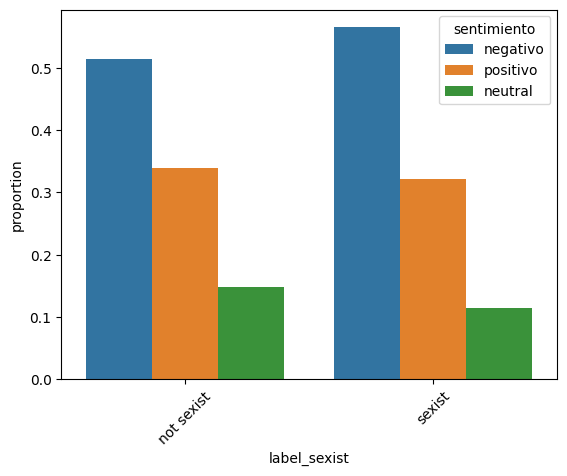

In [ ]:
tabla_frecuencia_relacion= datos_sexo.groupby('label_sexist')['sentimiento'].value_counts(normalize=True)
sns.barplot(data=tabla_frecuencia_relacion.reset_index(), x='label_sexist', y='proportion', hue='sentimiento')
plt.xticks(rotation=45)
plt.show()

Podemos ver que si el texto sexista o no, el sentimiento dominante va a ser negativo, aunque en los sexistas, el sentimiento negativo tiene una mayor proporción.

### Extracción de Entidades

In [ ]:
nlp = spacy.load("en_core_web_sm") # lectura del modelo
def extraer_entidades(texto):
  """
  Por cada noticia vamos a extraer la entidad de ORG, GPE y PERSON
  Retorna un texto con las entidades separadas por ,
  """
  doc = nlp(texto) # aplicamos el algoritmo
  entidades=[] # entidades
  # entidades=[w.text for w in doc.ents if w.label_  in ["ORG", "GPE", "PERSON"]]
  for ent in doc.ents:
    if ent.label_  in ["NORP", "PERSON", "ORG"]:
      entidades.append(ent.text) # añadimos a la lista
  entidades=','.join(entidades) # unimos la lista por comas
  entidades=entidades.lower() # todo a minúsculas
  return entidades

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
datos_sexo["entidades"]=datos_sexo["text"].apply(extraer_entidades)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Size of new BoW title = 411


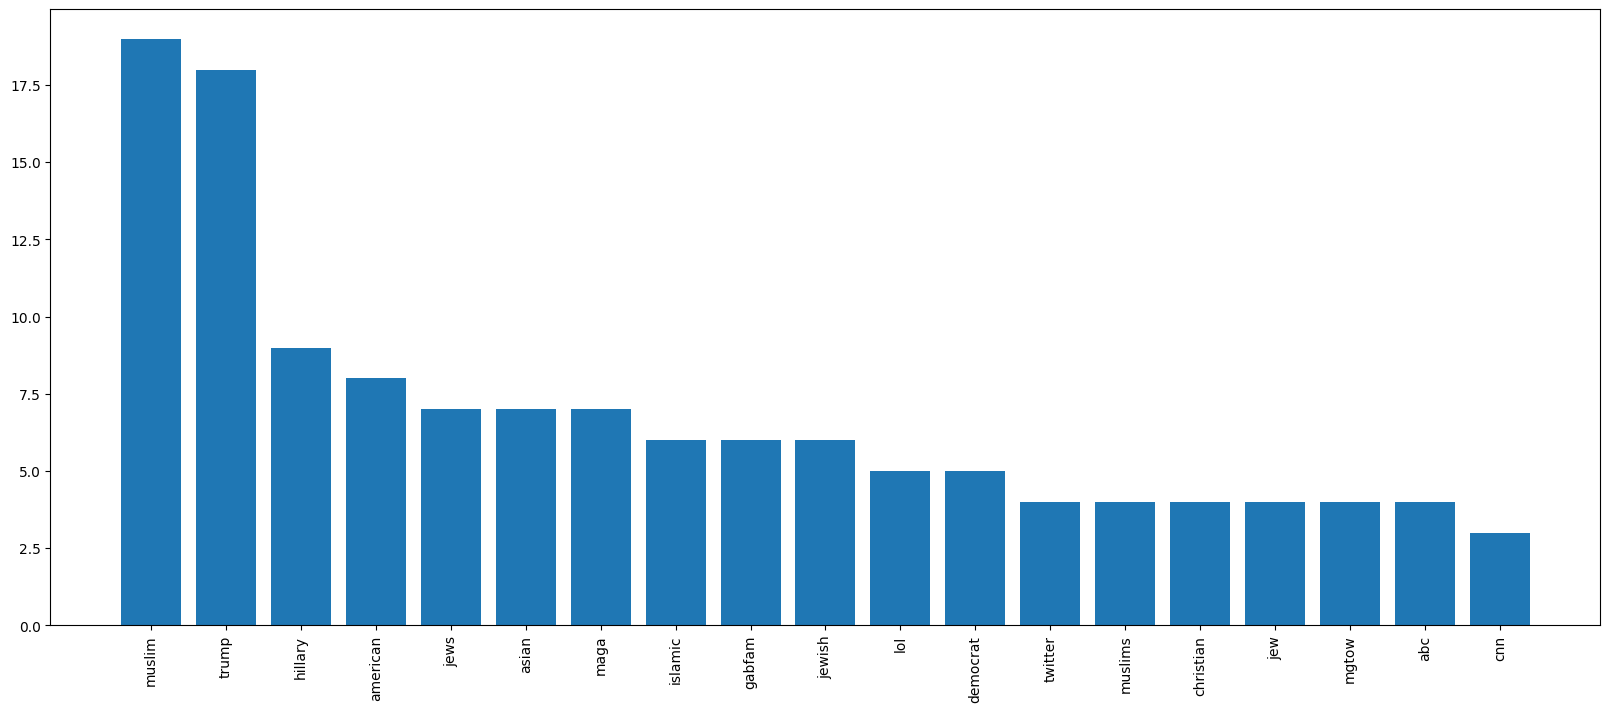

In [ ]:
texto_entidades=','.join(datos_sexo["entidades"])
texto_entidades = texto_entidades.split(',')
fdist = nltk.FreqDist(texto_entidades)
topwords = fdist.most_common(20)
print('Size of new BoW title =',len(fdist))
x,y = zip(*topwords)

plt.figure(figsize=(20,8))
plt.bar(x[1:],y[1:])
plt.xticks(rotation=90)
plt.show()

Para la extracción de entidades, decidí seleccionar Personas Famosas, Organizaciones y Grupos Etnicos, Religiosos o Políticos. Podemos ver que dentro de los textos sexistas, los musulmanes son los mas frecuentes. También podemos ver que trump y hillary se mencionan mucho. Otros grupos etnicos y religiosos tambien son mencionados como los judíos, asiaticos, etc.

### Limpieza

In [ ]:
stop_words_nltk_en =list(set(stopwords.words('english')))
stop_words_nltk_en = ["u", "ok", *stop_words_nltk_en]
stop_words_nltk_es =list(set(stopwords.words('spanish')))
def texto_limpio(texto, idioma ="en"):
  """
  Recibe un texto
  Retorna un texto sin simbolos, sin stopwords, en minusculas
  idioma = en (inglés) o es (español)
  """
  texto_limpio=str(texto).lower()
  # blob = TextBlob(texto_limpio )
  # texto_limpio= blob.correct().string
  if idioma=="es":
    texto_limpio = unidecode(texto_limpio) # elimina los acentos y ñ
  texto_limpio= re.sub(r'https?://\S+|www\.\S+', ' ', texto_limpio)  # eliminar la URL
  texto_limpio= re.sub(r"[^A-Za-z]+",' ',texto_limpio) # Eliminar simbolos
  texto_limpio = texto_limpio.split() # seperacion de tokens
  if idioma=="en":
    texto_limpio=[w for w in texto_limpio if w not in stop_words_nltk_en] # eliminacción de stop word
  elif idioma=="es":
    texto_limpio=[w for w in texto_limpio if w not in stop_words_nltk_es] # eliminacción de stop word
  texto_limpio=' '.join(texto_limpio)
  return texto_limpio

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
datos_sexo["text_limpio"]=datos_sexo["text"].apply(texto_limpio)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


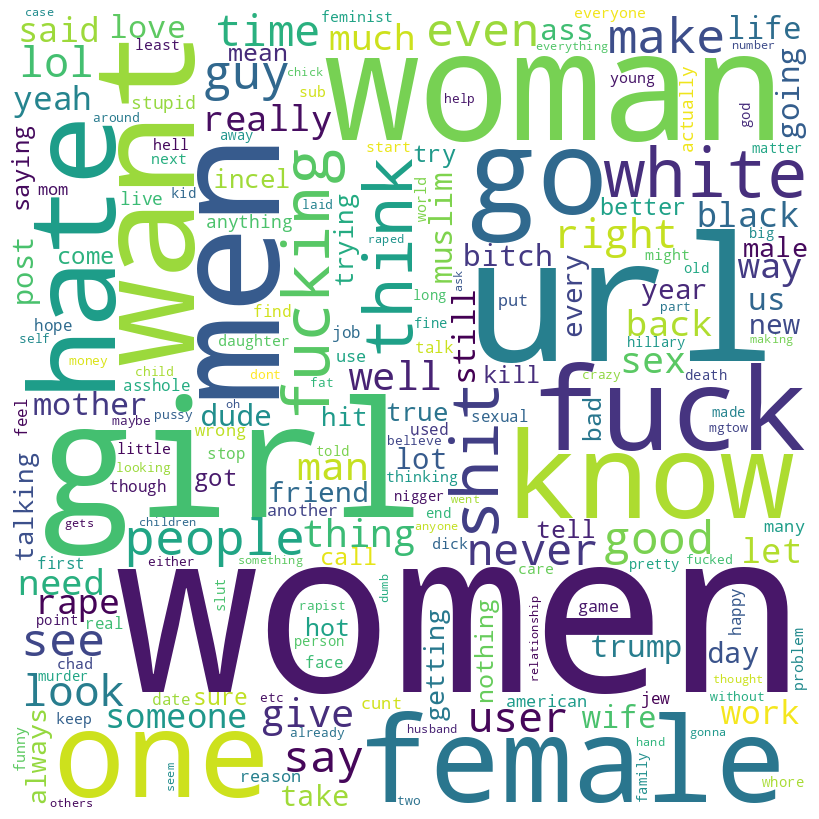

In [ ]:
texto_join =  " ".join(datos_sexo["text_limpio"])
wordcloud = WordCloud(width = 800, height = 800, background_color ='white', min_font_size = 10).generate(texto_join)
 # mostrar nube de palabras
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)
plt.show()

Dentro de las palabras mas mencionadas podemos ver:

*   women
*   female
* girl
* woman
* men

Principalmente, en la nube de palabras observamos palbras asociadas a genero, insultos, acciones negativas o sexuales, etc.



### LDA

In [ ]:
count_vectorizer = CountVectorizer(min_df=10,ngram_range=(1, 3))
X_count = count_vectorizer.fit_transform(datos_sexo["text_limpio"])
count_vectorizer.get_feature_names_out()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


array(['actually', 'already', 'also', 'always', 'another', 'anything',
       'around', 'ass', 'asshole', 'away', 'back', 'bad', 'believe',
       'better', 'big', 'bitch', 'black', 'call', 'care', 'chad', 'child',
       'children', 'come', 'could', 'crazy', 'day', 'death', 'dick',
       'dude', 'dumb', 'either', 'else', 'even', 'ever', 'every',
       'everyone', 'everything', 'face', 'family', 'fat', 'feel',
       'female', 'find', 'fine', 'first', 'free', 'friends', 'fuck',
       'fucked', 'fucking', 'funny', 'gabfam', 'game', 'get', 'gets',
       'getting', 'girl', 'girls', 'give', 'go', 'god', 'going', 'gonna',
       'good', 'got', 'guy', 'guys', 'happy', 'hate', 'hell', 'help',
       'high', 'hillary', 'hit', 'hope', 'hot', 'husband', 'job', 'keep',
       'kill', 'know', 'least', 'let', 'life', 'like', 'little', 'lol',
       'long', 'look', 'looking', 'looks', 'lot', 'love', 'made', 'make',
       'makes', 'making', 'male', 'man', 'many', 'mean', 'men', 'mgtow',
       '

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


<Axes: >

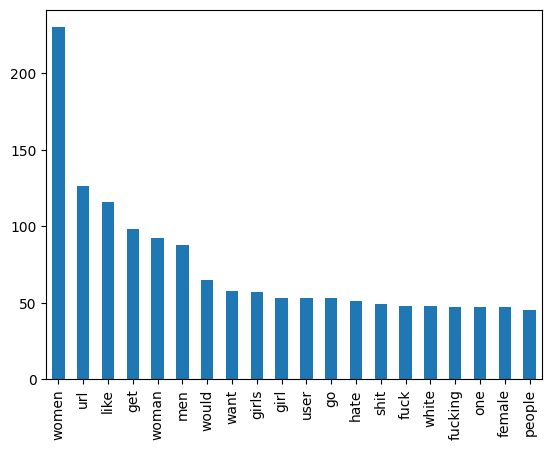

In [ ]:
datos_count=pd.DataFrame(X_count.toarray(), columns=count_vectorizer.get_feature_names_out())
datos_count.sum().sort_values(ascending=False).iloc[0:20].plot(kind="bar")

In [ ]:
#Creamos columna de tokens
count_vectorizer = CountVectorizer(min_df=10)
X_count = count_vectorizer.fit_transform(datos_sexo["text_limpio"])
datos_sexo["tokens"]=datos_sexo["text_limpio"].apply(lambda x: x.split())
datos_sexo["tokens"]

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,tokens
1130,"[need, like, share, go, picture, real, face, b..."
855,"[finding, girls, facebook, also, crazy, result..."
799,"[really, relinquish, parental, rights, jurisdi..."
1480,"[blackpilling, women, instantly, turns, whores..."
1561,"[hamster, doesnt, run, guys, shes, attracted]"
...,...
1683,"[damn, white, people, protesting, president, a..."
454,"[url, chemnitz, hit, protests, german, migrati..."
1763,"[dude, whatever, responsibility, read, mind, l..."
1153,"[bit, unethical, middle, age, ish, whole, cutt..."


In [ ]:
# Crear un diccionario y un corpus
dictionary = corpora.Dictionary([count_vectorizer.get_feature_names_out() ])
corpus = [dictionary.doc2bow(text.split()) for text in datos_sexo["text_limpio"]]

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
coherence_values = [] # parametro determinar tópicos
model_list = {} # modelos de tópicos
topicos_num= range(2,10)
for num_topics in topicos_num:
    model = gensim.models.LdaModel(corpus=corpus,
                                    id2word=dictionary,
                                    num_topics=num_topics,
                                    random_state=100,
                                    update_every=1,
                                    chunksize=100,
                                    passes=10,
                                    alpha='auto',
                                    per_word_topics=True)
    model_list[num_topics] = model
    coherencemodel = CoherenceModel(model=model, texts=datos_sexo["tokens"], dictionary=dictionary, coherence='c_v')
    coherence_values.append(coherencemodel.get_coherence())

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


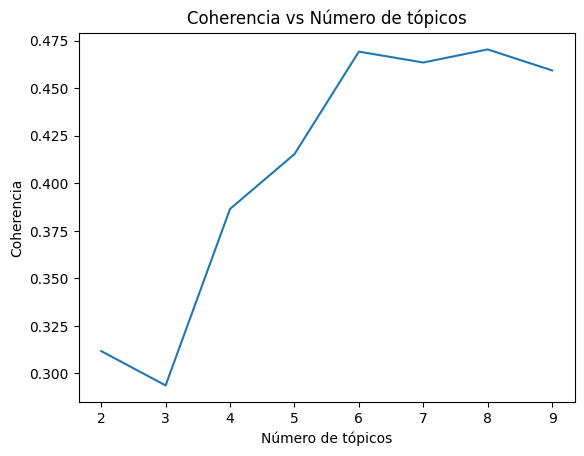

In [ ]:
x = range(2,10)
plt.plot(x, coherence_values)
plt.xlabel("Número de tópicos")
plt.ylabel("Coherencia")
plt.title("Coherencia vs Número de tópicos")
plt.show()

6 u 8 tópicos

In [ ]:
# Visualización interactiva
vis = pyLDAvis.gensim_models.prepare(model_list[5], corpus, dictionary)
pyLDAvis.display(vis)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
topics = model_list[5].print_topics(num_words=10)
for topic in topics:
    print(topic)

(0, '0.144*"url" + 0.090*"woman" + 0.047*"user" + 0.045*"people" + 0.041*"lol" + 0.032*"like" + 0.031*"right" + 0.029*"look" + 0.024*"trump" + 0.023*"us"')
(1, '0.075*"would" + 0.068*"go" + 0.065*"white" + 0.064*"fuck" + 0.058*"think" + 0.043*"yeah" + 0.043*"really" + 0.033*"also" + 0.032*"ass" + 0.030*"still"')
(2, '0.184*"women" + 0.080*"get" + 0.063*"like" + 0.063*"men" + 0.047*"fucking" + 0.046*"girls" + 0.034*"female" + 0.032*"one" + 0.030*"see" + 0.023*"sex"')
(3, '0.057*"hate" + 0.047*"know" + 0.046*"girl" + 0.045*"even" + 0.045*"want" + 0.034*"shit" + 0.033*"well" + 0.032*"let" + 0.031*"make" + 0.030*"man"')
(4, '0.095*"never" + 0.075*"good" + 0.060*"actually" + 0.059*"said" + 0.049*"getting" + 0.045*"thing" + 0.043*"wants" + 0.035*"new" + 0.034*"person" + 0.031*"ever"')


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
#Asignación de Cluster o Tópico
document_topics = model_list[5].get_document_topics(corpus)
dominant_topics = []
for doc_topics in document_topics:
    # Ordenar los tópicos por probabilidad y tomar el de mayor valor
    dominant_topic = max(doc_topics, key=lambda x: x[1])[0]  # x[1] es la probabilidad, x[0] es el ID del tópico
    dominant_topics.append(dominant_topic)
datos_sexo["dominant_topic"] = dominant_topics

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
datos_sexo["dominant_topic"].value_counts()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,count
dominant_topic,
2,454
3,231
0,196
1,99
4,20


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


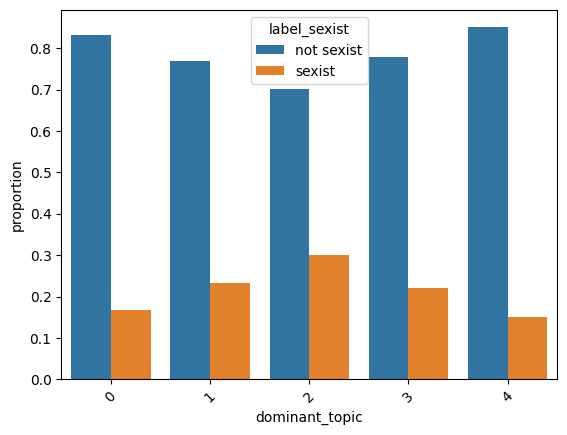

In [ ]:
tabla_frecuencia_relacion= datos_sexo.groupby('dominant_topic')['label_sexist'].value_counts(normalize=True)
sns.barplot(data=tabla_frecuencia_relacion.reset_index(), x='dominant_topic', y='proportion', hue='label_sexist')
plt.xticks(rotation=45)
plt.show()

Con esta distribución, podemos ver que el topico 2 tiene 454 textos y de estos cerca del 30% son sexistas. Dentro de las palabras de este topico podemos ver:

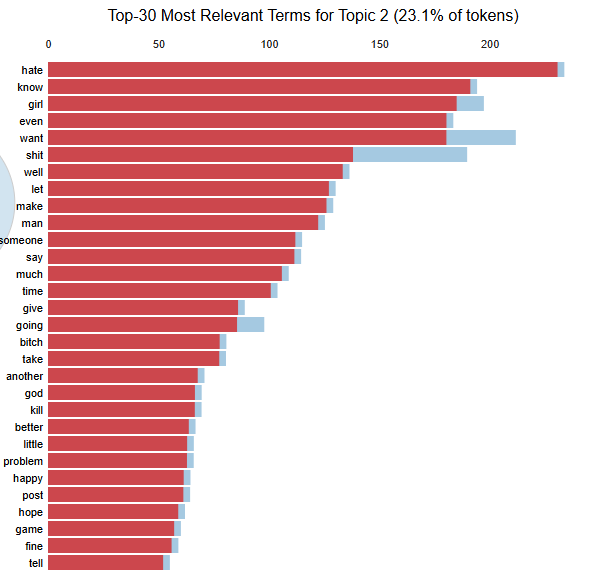

Estas palabras principalmente son de odio, podemos ver 'hate', 'shit', 'bitch', 'kill', etc.